In [21]:
from plots.utils import load_runs_from_wandb


In [22]:
run_names = [
    # Upsampler 1:
    "18M__2025.11.03_03.37",
    "18M_43_2025.11.03_03.37",
    "18M_44_2025.11.03_03.37",
    "18M_45_2025.11.03_08.32",
    "18M_46_2025.11.03_08.34",
    # Upsampler 2: 
    "18M__2025.11.04_08.01",
    "18M_43_2025.11.04_08.01",
    "18M_44_2025.11.04_12.51",
    "18M_45_2025.11.04_12.56",
    "18M_46_2025.11.04_17.44",
]

In [23]:
df, configs = load_runs_from_wandb(run_names)

In [24]:
df.head()

,_step,rate_consistency_loss,val_in_context_learning_score,_timestamp,batch_wallclock_time,true_downsample_rate,val_mean_selected_action_ce,model_flops_utilization,val_rate_consistency_loss,ar_loss,...,early_ar_loss,total_loss,downsample_rate_target,val_late_ar_loss,late_ar_loss,run_name,model_size,GaterClass,seed,UpsamplerClass
0,0,0.000000,-0.077751,1.762137e+09,0.952536,0.250000,0.560791,0.046881,-0.000092,8.634272,...,6.644122,8.633833,0.25,9.065004,9.131809,18M__2025.11.03_03.37,18M,ScaledSequentialyDependentLinearGater,42,NaN
1,1,-0.000204,NaN,1.762137e+09,0.603306,0.251953,NaN,0.073543,NaN,8.660822,...,6.664142,8.659994,0.25,NaN,9.159992,18M__2025.11.03_03.37,18M,ScaledSequentialyDependentLinearGater,42,NaN
2,2,-0.000204,NaN,1.762137e+09,0.603333,0.251953,NaN,0.074521,NaN,8.493310,...,6.632093,8.492387,0.25,NaN,8.958614,18M__2025.11.03_03.37,18M,ScaledSequentialyDependentLinearGater,42,NaN
3,3,0.000000,NaN,1.762137e+09,0.743391,0.250000,NaN,0.060224,NaN,8.633389,...,6.614164,8.632646,0.25,NaN,9.138194,18M__2025.11.03_03.37,18M,ScaledSequentialyDependentLinearGater,42,NaN
4,4,0.000633,NaN,1.762137e+09,0.578180,0.244141,NaN,0.075251,NaN,12.048243,...,5.424345,12.053188,0.25,NaN,13.704216,18M__2025.11.03_03.37,18M,ScaledSequentialyDependentLinearGater,42,NaN


In [25]:
df.keys()

Index(['_step', 'rate_consistency_loss', 'val_in_context_learning_score',
       '_timestamp', 'batch_wallclock_time', 'true_downsample_rate',
       'val_mean_selected_action_ce', 'model_flops_utilization',
       'val_rate_consistency_loss', 'ar_loss', '_runtime', 'val_ar_loss',
       'val_true_downsample_rate', 'non_padding_bytes',
       'in_context_learning_score', 'val_total_loss',
       'non_padding_bytes_elapsed', 'flops', 'learning_rate', 'gating_loss',
       'val_downsample_rate_target', 'val_gating_loss', 'all_bytes_elapsed',
       'mean_selected_action_ce', 'flops_elapsed', 'val_early_ar_loss',
       'all_bytes', 'pre_clip_grad_norm', 'early_ar_loss', 'total_loss',
       'downsample_rate_target', 'val_late_ar_loss', 'late_ar_loss',
       'run_name', 'model_size', 'GaterClass', 'seed', 'UpsamplerClass'],
      dtype='object')

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
val_steps = df["val_true_downsample_rate"].notna()
df_val = df[
    val_steps
]


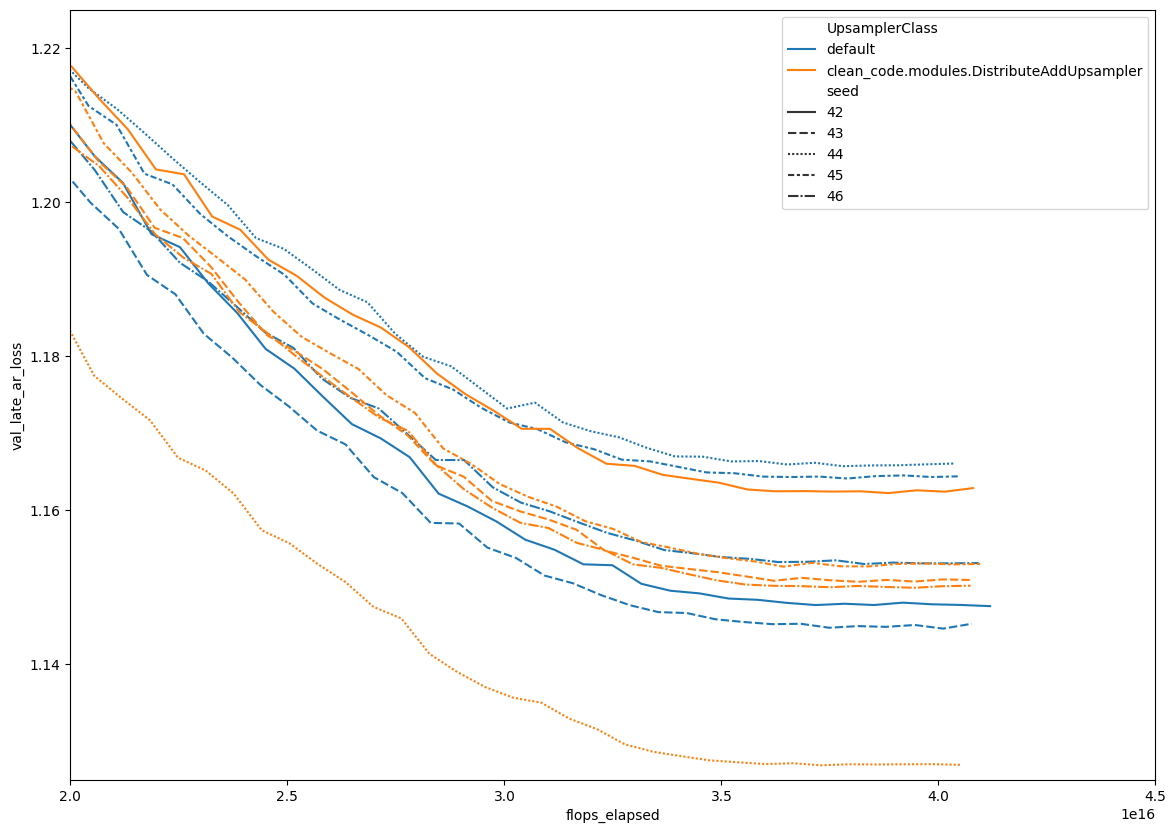

In [40]:
plt.figure(figsize=(14, 10))


df_val.loc[df_val["UpsamplerClass"].isna(), "UpsamplerClass"] = "default"
# df_val_mean = df_val.groupby("UpsamplerClass")["val_late_ar_loss", "flops_elapsed"].mean()

sns.lineplot(
    data=df_val,
    x="flops_elapsed",
    y="val_late_ar_loss",
    hue="UpsamplerClass",
    style="seed",
)

plt.xlim(2e16, 4.5e16)
plt.ylim(1.125, 1.225)

plt.show()